# Load and prepare data

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()
data = pd.read_csv("Salary_Data.csv")

print("Data loaded:")
print(data.head())

# Keep only relevant columns and drop missing values
data = data[["Age", "Years of Experience", "Salary"]].dropna()

X = data[["Age", "Years of Experience"]]
y = data["Salary"]


print(X.head(), "\n")

Saving Salary_Data.csv to Salary_Data (5).csv
Data loaded:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
    Age  Years of Experience
0  32.0                  5.0
1  28.0                  3.0
2  45.0                 15.0
3  36.0                  7.0
4  52.0                 20.0 



# Define Residual Sum of Squares (RSS)

In [ ]:
def rss(y): #y is a numpy array
    """Residual Sum of Squares"""
    mean_y = np.mean(y)
    return np.sum((y - mean_y) ** 2)

# Find the Best Split

In [ ]:
def find_best_split(X, y, min_leaf_size=3):
    n_samples, n_features = X.shape
    best_feature, best_threshold = None, None
    best_rss = rss(y)

    for j in range(n_features):
        x_j = X[:, j]
        unique_vals = np.unique(x_j)
        for s in unique_vals[:-1]:
            left_idx = np.where(x_j < s)[0]
            right_idx = np.where(x_j >= s)[0]
            if len(left_idx) < min_leaf_size or len(right_idx) < min_leaf_size:
                continue
            total_rss = rss(y[left_idx]) + rss(y[right_idx])
            if total_rss < best_rss:
                best_rss = total_rss
                best_feature = j
                best_threshold = s

    if best_feature is None or best_rss >= rss(y):
        return None
    return {"feature": best_feature, "threshold": best_threshold, "rss": best_rss}

# Recursive Tree Class

In [ ]:
class RecursiveTreeRegressor:
    """Recursive Binary Splitting"""

    def __init__(self, min_leaf_size=3):
        self.min_leaf_size = min_leaf_size
        self.tree = None
        self.feature_names = None

    def _build_tree(self, X, y):
        split = find_best_split(X, y, self.min_leaf_size)
        if split is None:
            return {"type": "leaf", "prediction": np.mean(y)}

        feat = split["feature"]
        thr = split["threshold"]
        left_idx = np.where(X[:, feat] < thr)[0]
        right_idx = np.where(X[:, feat] >= thr)[0]

        left_tree = self._build_tree(X[left_idx, :], y[left_idx])
        right_tree = self._build_tree(X[right_idx, :], y[right_idx])

        return {
            "type": "node",
            "feature": feat,
            "threshold": thr,
            "left": left_tree,
            "right": right_tree,
        }

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names = list(X.columns)
            X = X.values
        y = np.array(y)
        self.tree = self._build_tree(X, y)
        return self

    def _predict_one(self, node, x):
        while node["type"] != "leaf":
            if x[node["feature"]] < node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["prediction"]

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self._predict_one(self.tree, x) for x in X])

    def _print_node(self, node, depth=0):
        pad = "  " * depth
        if node["type"] == "leaf":
            print(f"{pad}→ Predict Salary: ${round(node['prediction'], 2)}")
        else:
            fname = (
                self.feature_names[node["feature"]]
                if self.feature_names
                else f"x{node['feature']}"
            )
            print(f"{pad}if {fname} < {round(node['threshold'], 3)}:")
            self._print_node(node["left"], depth + 1)
            print(f"{pad}else:")
            self._print_node(node["right"], depth + 1)

    def print_tree(self):
        self._print_node(self.tree)



# Fit the Tree

In [ ]:
tree = RecursiveTreeRegressor(min_leaf_size=3)
tree.fit(X, y)

print("\n--- Recursive Binary Splitting Tree ---")
tree.print_tree()


--- Recursive Binary Splitting Tree ---
if Years of Experience < 6.0:
  if Years of Experience < 3.0:
    if Years of Experience < 1.5:
      if Years of Experience < 0.5:
        if Age < 24.0:
          if Age < 22.0:
            → Predict Salary: $25000.0
          else:
            → Predict Salary: $39305.43
        else:
          → Predict Salary: $27176.7
      else:
        if Age < 28.0:
          if Age < 26.0:
            if Age < 24.0:
              → Predict Salary: $46733.75
            else:
              → Predict Salary: $53528.31
          else:
            → Predict Salary: $42309.28
        else:
          if Age < 29.0:
            → Predict Salary: $29476.19
          else:
            if Age < 31.0:
              → Predict Salary: $26666.67
            else:
              → Predict Salary: $25000.0
    else:
      if Age < 26.0:
        if Age < 24.0:
          → Predict Salary: $62837.0
        else:
          → Predict Salary: $79450.77
      else:
        if

# Evaluate Training Performance

In [ ]:
preds = tree.predict(X)
mse = np.mean((preds - y) ** 2)
rmse = np.sqrt(mse)

print(f"\nTraining MSE: {mse:.2f}")
print(f"Training RMSE: {rmse:.2f}")


Training MSE: 512024927.92
Training RMSE: 22627.97


# Prediction through User Input

In [ ]:
def predict_income(age, experience):
    x_input = np.array([[age, experience]])
    pred = tree.predict(x_input)[0]
    return round(pred, 2)

try:
    age_input = float(input("\nEnter Age: "))
    exp_input = float(input("Enter Years of Experience: "))

    predicted_salary = predict_income(age_input, exp_input)
    print(f"\n Predicted Income for Age {age_input} and {exp_input} years of experience: ${predicted_salary}")
except Exception as e:
    print("Error:", e)


Enter Age: 45
Enter Years of Experience: 26

 Predicted Income for Age 45.0 and 26.0 years of experience: $176339.93


## Heat Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset

df = data


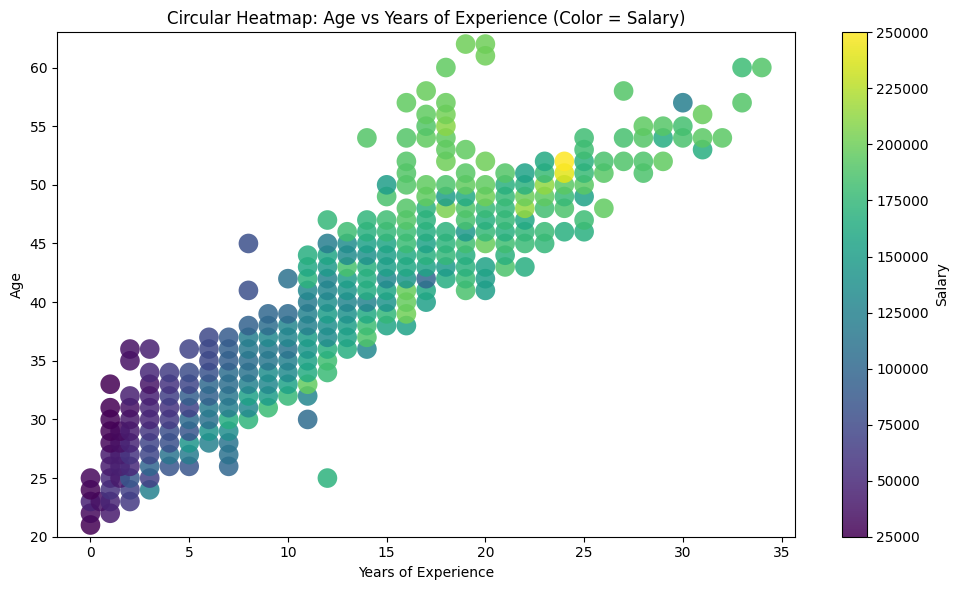

In [ ]:
# Pivot the data (mean salary per Age–Experience pair)
heatmap_data = df.pivot_table(
    values='Salary',
    index='Age',
    columns='Years of Experience',
    aggfunc='mean'
)

# Convert pivoted data into x, y, z format for scatter plotting
data_points = heatmap_data.stack().reset_index()
data_points.columns = ['Age', 'Years of Experience', 'Salary']

# Remove NaNs
data_points = data_points.dropna(subset=['Salary'])

# Create bubble heatmap
plt.figure(figsize=(10, 6))
ax = plt.gca()

sc = ax.scatter(
    data_points['Years of Experience'],
    data_points['Age'],
    c=data_points['Salary'],
    s=200,
    cmap='viridis',
    alpha=0.85,
    edgecolors='none'
)

# Ensure vertical axis increases upward (younger bottom → older top)
y_min = data_points['Age'].min()
y_max = data_points['Age'].max()
ax.set_ylim(y_min - 1, y_max + 1)  # ascending order = increases upward

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Salary')

# Labels and title
ax.set_title('Circular Heatmap: Age vs Years of Experience (Color = Salary)')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Age')

plt.tight_layout()
plt.show()